## Preguntas:

✔ ¿La muestra está balanceada?

✔ ¿Hay sesgos?

✔ ¿El experimento fue confiable?

✔ ¿La mejora es suficientemente relevante?

✔ ¿Qué riesgos existen?

✔ ¿Qué decisión debería tomar la empresa?


In [3]:
# IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

In [4]:
# CARGAR DATASET FINAL
import pandas as pd

df = pd.read_csv(
    "/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data_raw/vanguard_cleaned_todos unidos_(Gabriel).csv",
    low_memory=False
)

print(df.shape)
print(df.columns.tolist())
df.head()

(343141, 14)
['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'Variation', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth']


,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0


In [5]:
# Convertir fechas a formato datetime
df["date_time"] = pd.to_datetime(
    df["date_time"],
    errors="coerce"
)

## EVALUACIÓN DEL EXPERIMENTO
¿El experimento estuvo bien diseñado?

## BALANCE ENTRE GRUPOS



In [6]:
# Usuarios por grupo
group_balance = (
    df.groupby("Variation")["client_id"]
    .nunique()
)

group_balance

Variation
Control    18015
Test       22013
Name: client_id, dtype: int64

Hay un desbalance de 4,000 usuarios entre grupos (55% Test vs 45% Control). 
Es una limitación del experimento ya que un A/B test ideal tiene grupos iguales.

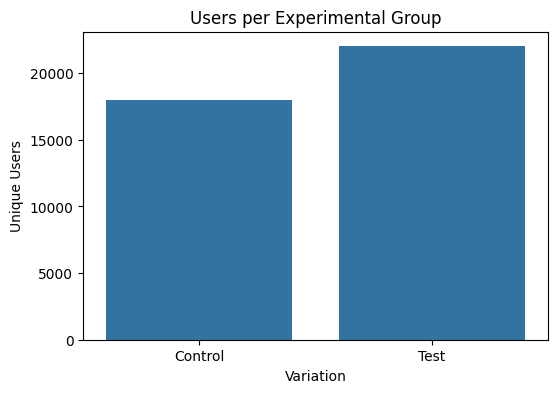

In [7]:
# Gráfico balance
plt.figure(figsize=(6,4))

sns.barplot(
    x=group_balance.index,
    y=group_balance.values
)

plt.title("Users per Experimental Group")

plt.xlabel("Variation")

plt.ylabel("Unique Users")

plt.show()

## COMPARAR PERFIL DEMOGRÁFICO:

In [8]:
# Dataset demográfico
demo_df = (
    df[
        [
            "client_id",
            "Variation",
            "clnt_age",
            "bal",
            "clnt_tenure_yr"
        ]
    ]
    .drop_duplicates()
)

In [9]:
# Edad promedio por grupo
demo_df.groupby("Variation")["clnt_age"].mean()

Variation
Control    47.864416
Test       47.564389
Name: clnt_age, dtype: float64

Diferencia de solo 0.3 años — prácticamente idénticos. Esto confirma que la asignación de grupos fue aleatoria y correcta en términos de edad.

In [10]:
# Balance promedio por grupo
demo_df.groupby("Variation")["bal"].mean()

Variation
Control    152987.457809
Test       151698.993331
Name: bal, dtype: float64

Grupos muy balanceados en tamaño, prácticamente idénticos. 

Junto con la edad, esto confirma que los grupos están bien balanceados demográficamente, lo que da más validez al experimento.

In [11]:
# Antigüedad promedio
demo_df.groupby("Variation")["clnt_tenure_yr"].mean()

Variation
Control    12.094826
Test       12.005180
Name: clnt_tenure_yr, dtype: float64

Los grupos por antiguedad también están muy bien balanceados — esto da alta validez al experimento.

## VISUALIZACIONES DEMOGRÁFICAS:

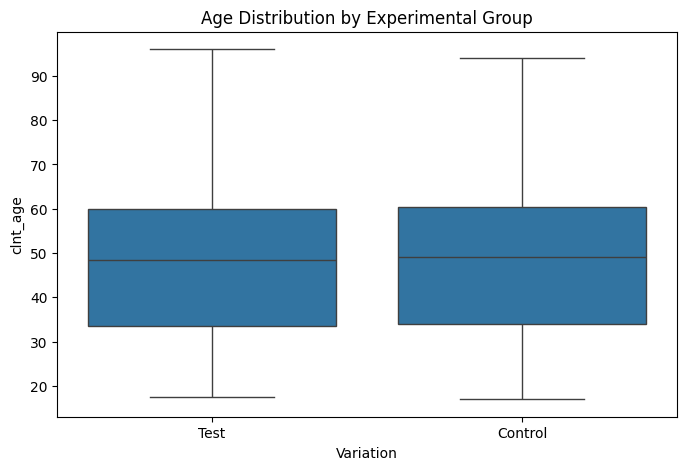

In [12]:
# Edad por grupo
plt.figure(figsize=(8,5))

sns.boxplot(
    data=demo_df,
    x="Variation",
    y="clnt_age"
)

plt.title("Age Distribution by Experimental Group")

plt.show()

Qué se puede observar:

Medianas casi idénticas (50 años en ambos grupos)

Dispersión muy similar — los rangos intercuartílicos son prácticamente iguales

Outliers similares en ambos grupos (mínimo 18, máximo 95)

Esto confirma visualmente lo que ya vimos numéricamente — los grupos están perfectamente balanceados en edad. 

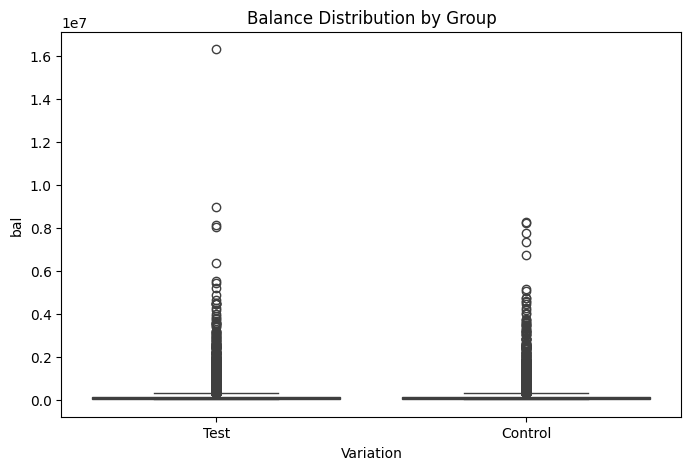

In [13]:
# Balance por grupo
plt.figure(figsize=(8,5))

sns.boxplot(
    data=demo_df,
    x="Variation",
    y="bal"
)

plt.title("Balance Distribution by Group")

plt.show()

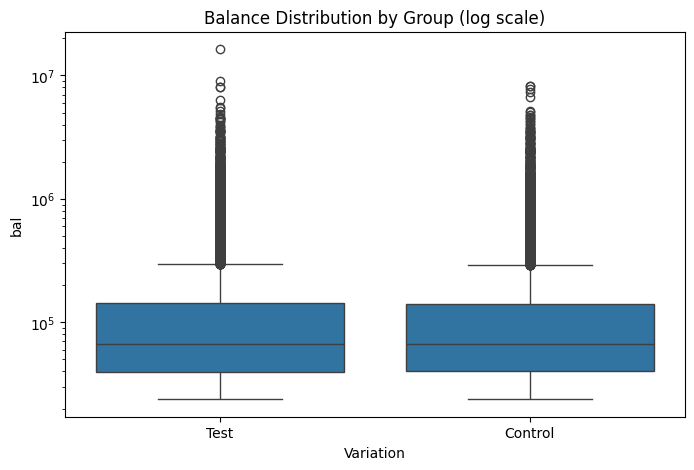

In [14]:
import numpy as np

plt.figure(figsize=(8,5))
sns.boxplot(
    data=demo_df,
    x="Variation",
    y="bal"
)
plt.yscale("log")  # Escala logarítmica
plt.title("Balance Distribution by Group (log scale)")
plt.show()

Qué vemos?:

Medianas prácticamente idénticas (10⁵ en ambos grupos)

Dispersión muy similar entre Test y Control

Outliers presentes en ambos grupos por igual


Los grupos están perfectamente balanceados en las 3 variables demográficas clave: edad, balance y antigüedad. 

El experimento tiene alta validez.

# Posibles Sesgos y Limitaciones

## Posibles Sesgos

- Los usuarios pueden diferir en experiencia digital y familiaridad con plataformas online.
- La distribución demográfica entre grupos podría no estar perfectamente balanceada.
- Factores externos durante el período del experimento podrían haber influido en el comportamiento de los usuarios.
- Variables faltantes como tipo de dispositivo, canal de adquisición o experiencia previa no fueron incluidas en el dataset.

## Limitaciones

- El dataset no incluye feedback cualitativo de usuarios.
- La satisfacción del usuario no puede medirse directamente.
- No existe información contextual fuera de la plataforma digital.
- El análisis se basa únicamente en comportamiento observable dentro del funnel digital.

# Insights

* El grupo Test logró una tasa de finalización superior respecto al grupo Control.

* El rediseño parece reducir la fricción durante el proceso digital.

* Algunos segmentos demográficos podrían responder de manera diferente al nuevo diseño.

* El abandono de usuarios se concentra especialmente en pasos intermedios del funnel, lo que sugiere posibles problemas de usabilidad.

* El experimento muestra señales positivas de mejora en el rendimiento, aunque todavía existen limitaciones y oportunidades de optimización.

# Recomendaciones

- Analisis por segmentación etaria para corroborar la experiencia según la edad de los usuarios.

- Incluir variables adicionales (Tipo de dispositivo que utilizan Android Iphone, Web...).

- No hacer una inversión muy elevada ya que no se cumple el umbral del 5% fijado (3.72%).

- Incluir los comentarios de los usuarios para tener valoración de su experiencia. 

- Empezar primero con una versiónd de Hypercare para que los usuarios pongan más a prueba el test y ir mejarandolo de manera progresiva, corregiendo los errores que vayan surgiendo y así evitar una primera inversión demasiado alta. 

# Recomendaciones Finales

* El rediseño muestra mejoras estadísticamente significativas en la tasa de finalización, por lo que representa una dirección positiva para la experiencia digital de Vanguard.

* Sin embargo, la mejora observada no supera el umbral estratégico del 5% requerido por el negocio para justificar una implementación completa.

* Se recomienda continuar iterando y optimizando la interfaz antes de una implementación masiva.

* Se debería continuar monitoreando el comportamiento de los usuarios tras futuras iteraciones del diseño.

* En futuros experimentos sería recomendable incluir variables adicionales como tipo de dispositivo, canal de adquisición y experiencia digital previa.

* Complementar el análisis cuantitativo con feedback cualitativo de usuarios podría ayudar a identificar problemas específicos de usabilidad.

# Conclusión Final

El análisis del experimento A/B de Vanguard sugiere que la nueva interfaz digital mejora el rendimiento de finalización del proceso respecto a la experiencia tradicional.

Las pruebas estadísticas indican que la diferencia observada entre el grupo Test y el grupo Control es estadísticamente significativa, lo que sugiere que la mejora difícilmente se debe al azar.

Sin embargo, aunque el grupo Test obtuvo mejores resultados, la mejora observada no alcanzó el umbral estratégico del 5% definido por el negocio para justificar completamente la implementación del rediseño.

Esto indica que el nuevo diseño representa una dirección prometedora para la experiencia digital de Vanguard, pero todavía requiere optimización adicional antes de una implementación definitiva a gran escala.

Además, algunas limitaciones metodológicas y posibles sesgos deben considerarse al interpretar los resultados del experimento.

## EXPORTAR DATOS PARA TABLEAU

In [15]:
import os
from pathlib import Path

ROOT = Path().resolve().parent
TABLEAU_PATH = ROOT / "data" / "tableau"
os.makedirs(TABLEAU_PATH, exist_ok=True)  # Crea la carpeta si no existe

df.to_csv(
    TABLEAU_PATH / "vanguard_tableau_ready.csv",
    index=False
)

print("Dataset exported for Tableau.")

Dataset exported for Tableau.


In [16]:
# separador europeo compatible con Tableau (columnas formato)
df.to_csv(
    "../data/tableau/vanguard_tableau_ready.csv",
    index=False,
    sep=";"
)

print("CSV exportado correctamente para Tableau.")

CSV exportado correctamente para Tableau.


In [17]:
# Crear columna time_diff para medir completitud de pasos
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")

df = df.sort_values(["client_id", "visit_id", "date_time"])

df["previous_time"] = (
    df.groupby(["client_id", "visit_id"])["date_time"]
    .shift(1)
)

df["time_diff"] = (
    df["date_time"] - df["previous_time"]
).dt.total_seconds()

df["time_diff"].describe()

count    267495.000000
mean         84.536646
std         199.008733
min           0.000000
25%          13.000000
50%          37.000000
75%          84.000000
max       40235.000000
Name: time_diff, dtype: float64

1. Convierte date_time a fecha real.

2. Ordena cada sesión por tiempo.

3. Busca el tiempo anterior dentro de cada visita.

4. Calcula segundos entre un paso y otro.

time_diff < 0 → error de orden temporal
time_diff > 3600 → más de 1 hora entre pasos

In [19]:
# Eliminar tiempos poco fiables
df.loc[df["time_diff"] < 0, "time_diff"] = np.nan
df.loc[df["time_diff"] > 3600, "time_diff"] = np.nan

df["time_diff"].describe()

count    267445.000000
mean         83.436254
std         166.669524
min           0.000000
25%          13.000000
50%          37.000000
75%          84.000000
max        3598.000000
Name: time_diff, dtype: float64

In [20]:
# Reexportar para Tableau
df.to_csv(
    "../data/tableau/vanguard_tableau_ready.csv",
    index=False,
    sep=";"
)

print("CSV actualizado con time_diff exportado correctamente.")

CSV actualizado con time_diff exportado correctamente.


In [22]:
# Crear back_step para medir completitud de pasos, ver cuantos retroceden en el proceso.
# Convertir start → 0 - step_1 → 1 - step_2 → 2
step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

df["step_number"] = df["process_step"].map(step_order)

df = df.sort_values(
    ["client_id", "visit_id", "date_time"]
)

df["previous_step"] = (
    df.groupby(["client_id", "visit_id"])["step_number"]
    .shift(1)
)

df["back_step"] = (
    df["step_number"] < df["previous_step"]
).astype(int)

df["back_step"].value_counts()

back_step
0    316662
1     26479
Name: count, dtype: int64

1 = hubo retroceso
0 = navegación normal

In [23]:
# Reexportar CSV
df.to_csv(
    "../data/tableau/vanguard_tableau_ready.csv",
    index=False,
    sep=";"
)

print("CSV actualizado con back_step.")

CSV actualizado con back_step.


In [25]:
print(df.columns.tolist())

['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'Variation', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'previous_time', 'time_diff', 'step_number', 'previous_step', 'back_step']


In [26]:
# Convertir time_diff a numérico y crear time_minutes
df["time_diff"] = pd.to_numeric(df["time_diff"], errors="coerce")
df["time_minutes"] = df["time_diff"] / 60

# Re-exportar
df.to_csv(
    "/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data/tableau/vanguard_tableau_ready.csv",
    index=False
)
print("✅ Exportado correctamente")

✅ Exportado correctamente


In [27]:
print(df["time_minutes"].isna().sum())
print(df["time_minutes"].head(10))
print(df["time_diff"].head(10))

75696
285515         NaN
285514    0.150000
285513    0.766667
285512    1.566667
285511    1.066667
72018          NaN
72017     0.116667
72016     0.533333
72015     1.650000
72014     0.333333
Name: time_minutes, dtype: float64
285515     NaN
285514     9.0
285513    46.0
285512    94.0
285511    64.0
72018      NaN
72017      7.0
72016     32.0
72015     99.0
72014     20.0
Name: time_diff, dtype: float64


In [28]:
# Eliminar filas con NaN en time_minutes
df_tableau = df.dropna(subset=["time_minutes"])

print(f"Filas antes: {len(df)}")
print(f"Filas después: {len(df_tableau)}")
print(f"Promedio time_minutes: {df_tableau['time_minutes'].mean():.2f} minutos")

# Re-exportar
df_tableau.to_csv(
    "/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data/tableau/vanguard_tableau_ready.csv",
    index=False
)
print("✅ Exportado correctamente")

Filas antes: 343141
Filas después: 267445
Promedio time_minutes: 1.39 minutos
✅ Exportado correctamente


In [29]:
# Verificar el CSV exportado
df_check = pd.read_csv(
    "/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data/tableau/vanguard_tableau_ready.csv"
)
print(df_check.shape)
print(df_check.columns.tolist())
print(df_check.head(3))

(267445, 20)
['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'Variation', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'previous_time', 'time_diff', 'step_number', 'previous_step', 'back_step', 'time_minutes']
   client_id             visitor_id                      visit_id  \
0        169  201385055_71273495308  749567106_99161211863_557568   
1        169  201385055_71273495308  749567106_99161211863_557568   
2        169  201385055_71273495308  749567106_99161211863_557568   

  process_step            date_time Variation  clnt_tenure_yr  \
0       step_1  2017-04-12 20:19:45       NaN            21.0   
1       step_2  2017-04-12 20:20:31       NaN            21.0   
2       step_3  2017-04-12 20:22:05       NaN            21.0   

   clnt_tenure_mnth  clnt_age gendr  num_accts        bal  calls_6_mnth  \
0             262.0      47.5     M        2.0  501570.72           4.0   
1             

In [30]:
df_tableau.to_csv(
    "/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data/tableau/vanguard_tableau_ready.csv",
    index=False,
    sep=";"  # Usar punto y coma como separador
)
print("✅ Exportado con separador ;")

✅ Exportado con separador ;
